<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-01-20 12:08:46--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  46.7MB/s    in 4.4s    

2026-01-20 12:08:51 (46.3 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 133.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 149.3 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 100.1 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


In [9]:
## Write your code here
q='''
select CompTotal
from main
'''
df=pd.read_sql_query(q, conn)

In [10]:
df.dropna(inplace=True)

In [11]:
df = df.drop(df[df['CompTotal'] == 0].index)

In [12]:
q1= df['CompTotal'].quantile(0.25)
q3= df['CompTotal'].quantile(0.75)
iqr=q3-q1
up = q3+1.5*iqr
out=df[df['CompTotal'] > up].index

In [13]:
df=df.drop(out)

In [15]:
!pip install seaborn
import seaborn as sns

(0.0, 561749.9500000001)

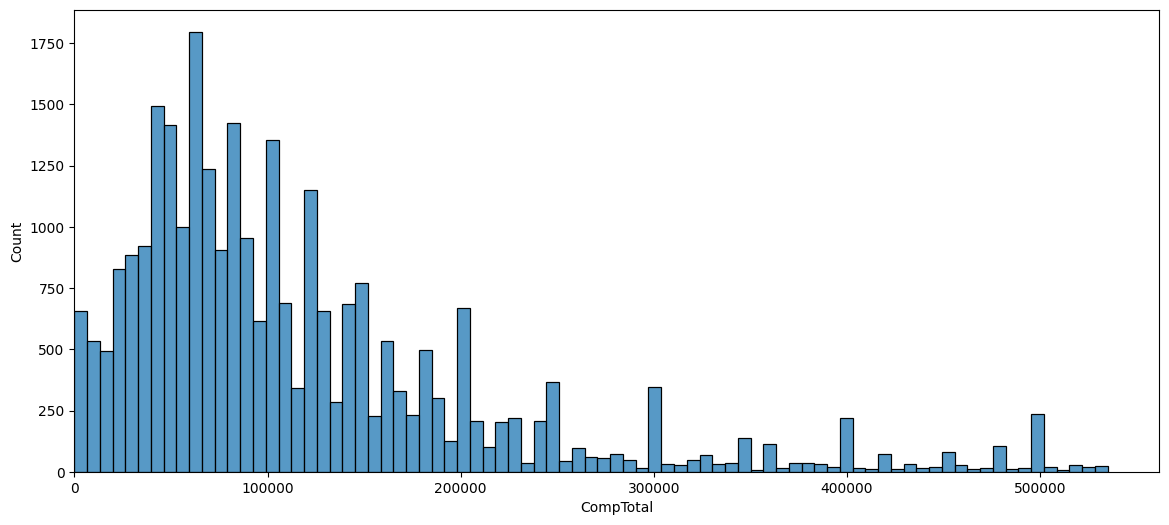

In [16]:
plt.figure(figsize=(14,6))
sns.histplot(df, x='CompTotal')
plt.xlim(0,)

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [17]:
## Write your code here
q= '''
SELECT  YearsCodePro
FROM main
'''
df=pd.read_sql_query(q, conn)

In [18]:
df.shape

(65437, 1)

In [19]:
df['YearsCodePro'] = df['YearsCodePro'].replace({'Less than 1 year' : 0.6,
                                                 'More than 50 years' : 60})


In [20]:
df.dtypes
df['YearsCodePro'] = df['YearsCodePro'].astype(float)

In [21]:
df.dropna(inplace=True)

In [22]:
num = df['YearsCodePro'].unique()
num

array([17. , 27. ,  7. , 11. , 25. , 12. , 10. ,  3. ,  0.6, 18. , 37. ,
       15. , 20. ,  6. ,  2. , 16. ,  8. , 14. ,  4. , 45. ,  1. , 24. ,
       29. ,  5. , 30. , 26. ,  9. , 33. , 13. , 35. , 23. , 22. , 31. ,
       19. , 21. , 28. , 34. , 32. , 40. , 50. , 39. , 44. , 42. , 41. ,
       36. , 38. , 60. , 43. , 47. , 48. , 46. , 49. ])

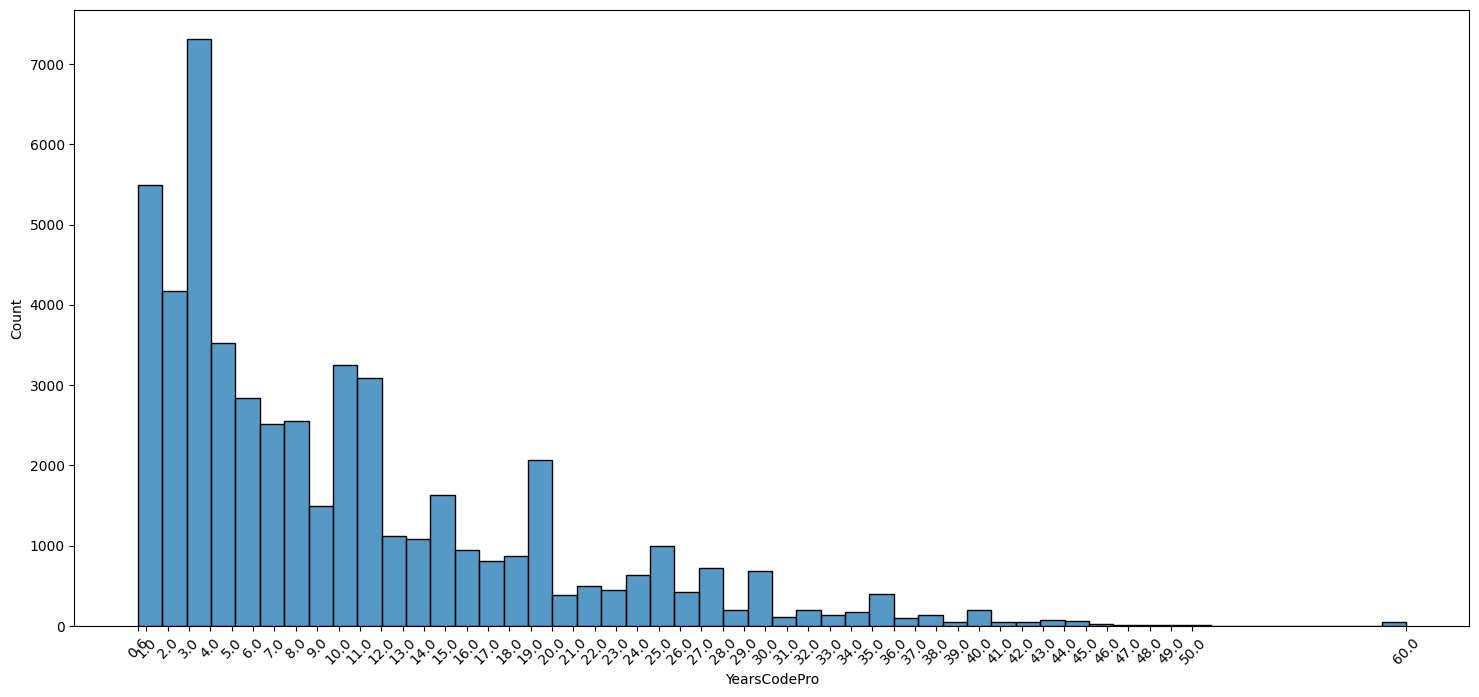

In [23]:
plt.figure(figsize=(18,8))
sns.histplot(df, x='YearsCodePro', bins=52)
plt.xticks(num,rotation=45);

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


In [24]:
q='''
SELECT CompTotal, Age
FROM main
'''
df=pd.read_sql_query(q,conn)

In [25]:
age_map = {'35-44 years old': (44+35)/2,
           'Under 18 years old' : 16,
           '18-24 years old' : (24+18)/2,
           '25-34 years old' : (34+25)/2,
           '45-54 years old' : (54+45)/2,
           '55-64 years old' : (64+55)/2,
           '65 years or older' : (65+80)/2}
df['Age'] = df['Age'].map(age_map)

In [26]:
df.dropna(inplace=True)

In [27]:
q1= df['CompTotal'].quantile(0.25)
q3= df['CompTotal'].quantile(0.75)
iqr=q3-q1
up = q3+1.5*iqr
out=df[df['CompTotal'] > up].index

In [28]:
df=df.drop(out)

In [29]:
df = df.groupby(['Age']).median()
df = df.reset_index()
df

,Age,CompTotal
0,16.0,10000.0
1,21.0,48000.0
2,29.5,80000.0
3,39.5,100000.0
4,49.5,115000.0
5,59.5,124110.0
6,72.5,120000.0


<Axes: xlabel='Age', ylabel='CompTotal'>

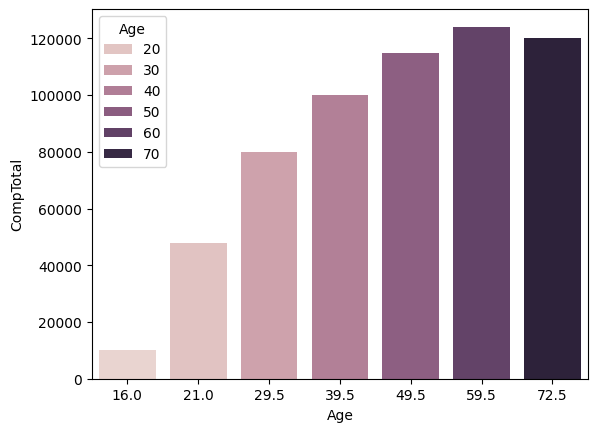

In [30]:
sns.barplot(df, x='Age', y='CompTotal', hue='Age')

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


In [31]:
q='''
SELECT TimeSearching, Age
FROM main
'''
df=pd.read_sql_query(q, conn)

In [32]:
time_map={'Less than 15 minutes a day' : 7.5,
          '15-30 minutes a day' : (30+15)/2,
          '30-60 minutes a day' : (30+60)/2,
          '60-120 minutes a day' : (60+120)/2,
          'Over 120 minutes a day' :(120+200)/2}
df['TimeSearching']=df['TimeSearching'].map(time_map)

In [33]:
df.dropna(inplace=True)

In [34]:
df=df.groupby(['Age']).mean()

In [35]:
df=df.reset_index()

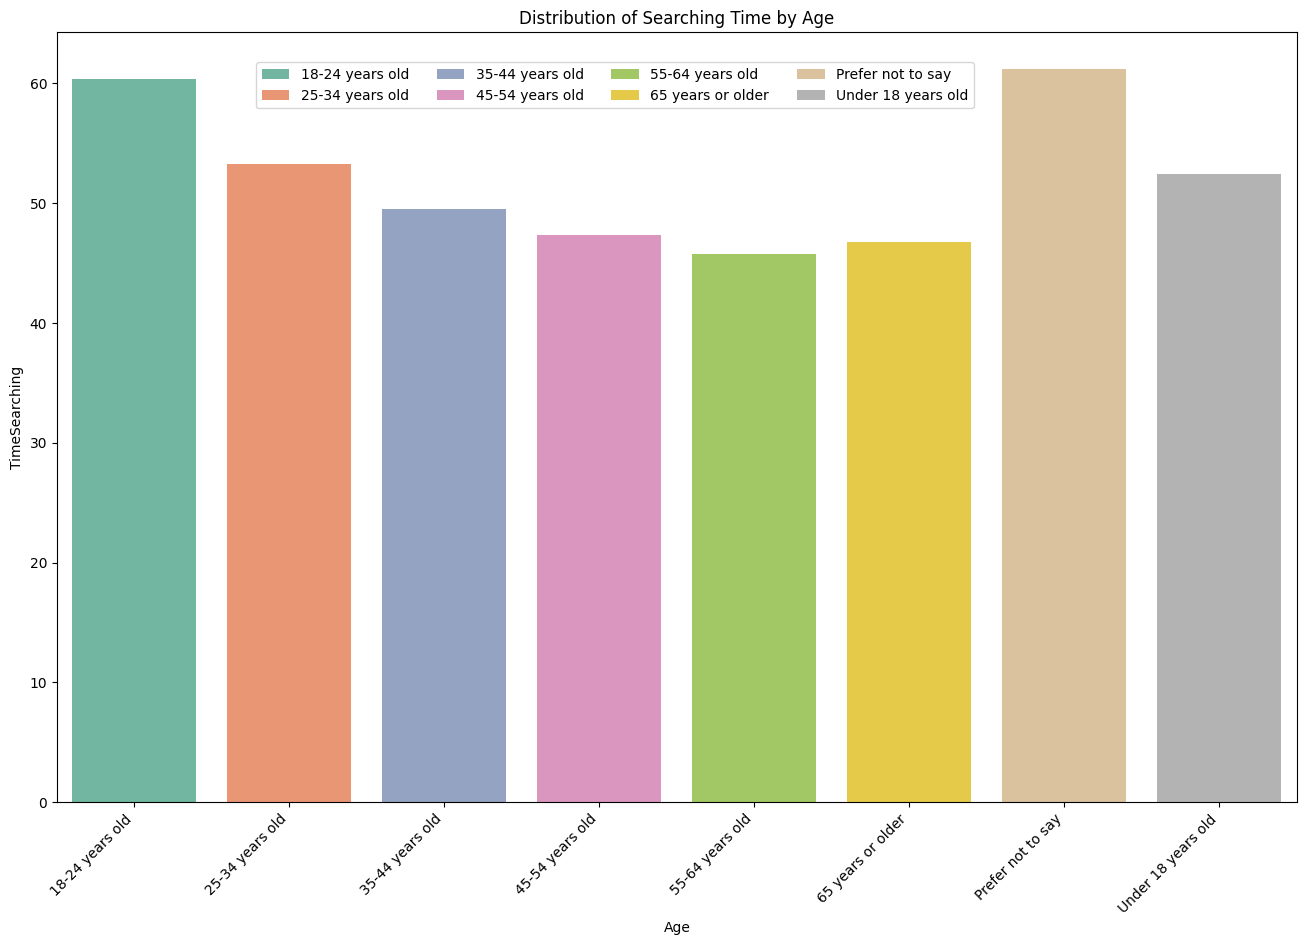

In [36]:
plt.figure(figsize=(16,10))
sns.barplot(df, x='Age', y='TimeSearching', hue='Age', legend='full', palette='Set2')
plt.title('Distribution of Searching Time by Age')
plt.legend(loc='upper center',bbox_to_anchor=(0.45,0.97 ), ncol=4)
plt.xticks(rotation=45, ha='right');

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


In [37]:
## Write your code here
q = '''
SELECT DatabaseWantToWorkWith
FROM main
'''
df=pd.read_sql_query(q,conn)

In [38]:
df.dropna(inplace=True)

In [39]:
df['DatabaseWantToWorkWith']=df['DatabaseWantToWorkWith'].str.split(';')
df=df.explode('DatabaseWantToWorkWith').reset_index(drop=True)
df

,DatabaseWantToWorkWith
0,PostgreSQL
1,Firebase Realtime Database
2,MongoDB
3,MySQL
4,PostgreSQL
...,...
127434,PostgreSQL
127435,SQLite
127436,MongoDB
127437,MySQL


In [40]:
df['Count']=1

In [41]:
df = df.groupby(['DatabaseWantToWorkWith']).sum()

In [42]:
df = df.sort_values(by='Count',ascending=False).head(5)

Text(0.5, 1.0, 'Top 5 Databases People Want To Learn')

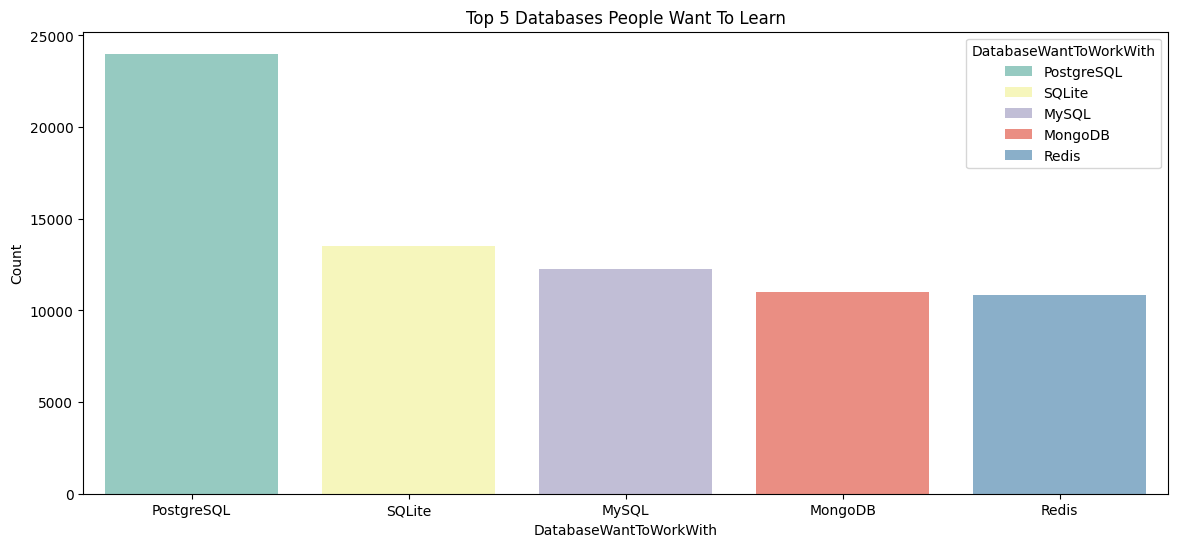

In [43]:
plt.figure(figsize=(14,6))
sns.barplot(df, x='DatabaseWantToWorkWith', y='Count', hue='DatabaseWantToWorkWith', legend='full', palette='Set3')
plt.title('Top 5 Databases People Want To Learn')

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [44]:
q='''
SELECT RemoteWork
FROM main
'''
df=pd.read_sql_query(q, conn)

In [45]:
df['Count']=1

In [46]:
df=df.groupby(['RemoteWork']).sum()

In [47]:
df.reset_index(inplace=True)

Text(0.5, 1.0, 'Distribution of Preffered Work Arrangements')

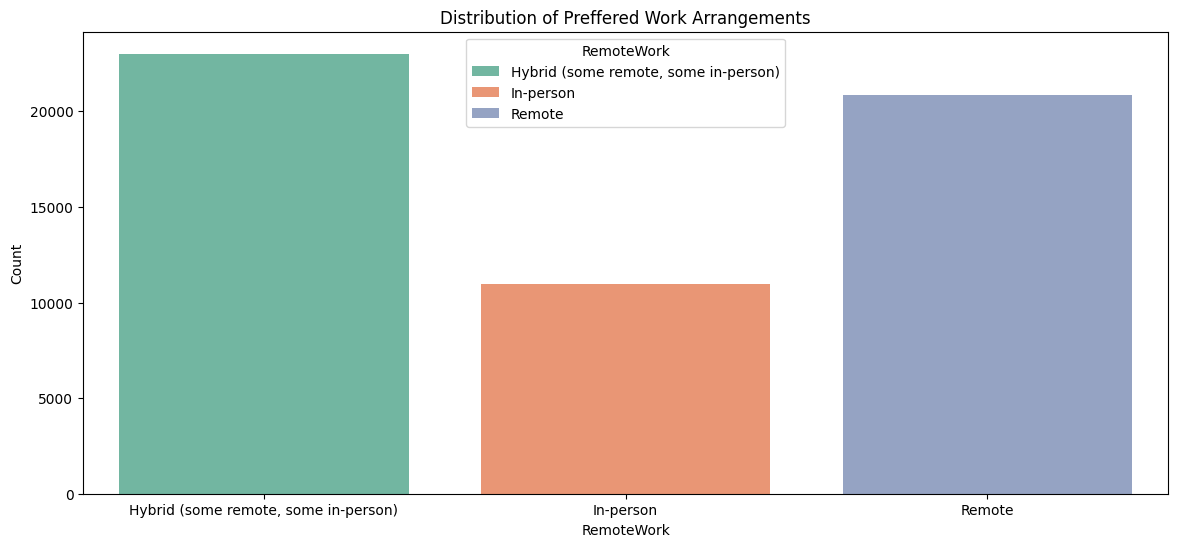

In [48]:
plt.figure(figsize=(14,6))
sns.barplot(df, x='RemoteWork', y='Count', hue='RemoteWork', legend='full', palette='Set2')
plt.title('Distribution of Preffered Work Arrangements')

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


In [55]:
q='''
SELECT CompTotal, Age
FROM main
'''
df=pd.read_sql_query(q, conn)

In [56]:
df.dropna(inplace=True)

In [57]:
age_map = {'35-44 years old': (44+35)/2,
           'Under 18 years old' : 16,
           '18-24 years old' : (24+18)/2,
           '25-34 years old' : (34+25)/2,
           '45-54 years old' : (54+45)/2,
           '55-64 years old' : (64+55)/2,
           '65 years or older' : (65+80)/2}
df['Age'] = df['Age'].map(age_map)

In [58]:
q1=df['CompTotal'].quantile(0.25)
q3=df['CompTotal'].quantile(0.75)
iqr=q3-q1
up=q3+1.5*iqr
out=df[df['CompTotal'] > up].index
df=df.drop(out)

In [59]:
df.max()

CompTotal    535000.0
Age              72.5
dtype: float64

In [62]:
df=df[(df['Age'] > 45)&(df['Age'] < 60)]
df=df.groupby(['Age']).median()

In [71]:
df.reset_index(inplace=True)

In [72]:
leg={49.5 :'45-54 years old', 59.5:'55-64 years old'}
df['Age']=df['Age'].map(leg)

Text(0.5, 1.0, 'Compensation Distribution among mid-career Respondents')

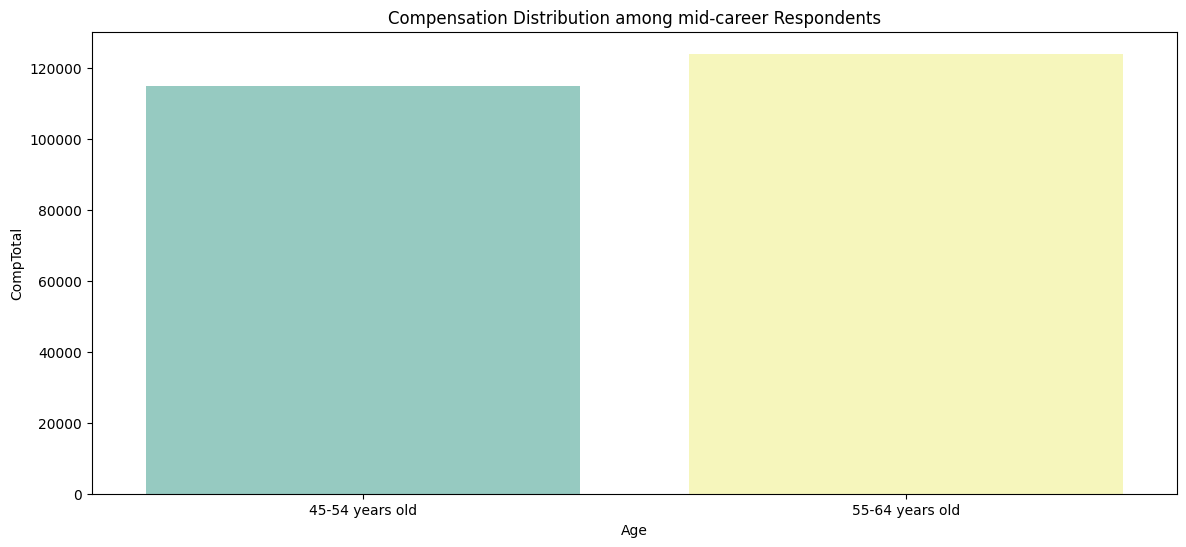

In [80]:
plt.figure(figsize=(14,6))
sns.barplot(df, x='Age', y='CompTotal', hue='Age', palette='Set3', legend=None)
plt.title('Compensation Distribution among mid-career Respondents')

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [153]:
## Write your code here
q='''
SELECT JobSat, YearsCodePro
FROM main
'''
df=pd.read_sql_query(q, conn)

In [154]:
df.isnull().sum()

JobSat          36311
YearsCodePro    13827
dtype: int64

In [155]:
df.dropna(inplace=True)

In [156]:
df['YearsCodePro']=df['YearsCodePro'].replace({'Less than 1 year': 0.6, 'More than 50 years': 60})

In [157]:
df['YearsCodePro']=df['YearsCodePro'].astype(float)

In [158]:
import numpy as np

In [159]:
bins=np.linspace(0, max(df['YearsCodePro']), 11)

In [160]:
bins

array([ 0.,  6., 12., 18., 24., 30., 36., 42., 48., 54., 60.])

In [161]:
grn=['0-6 Years', '6-12 Years', '12-18 Years', '18-24 Years', '24-30 Years', '30-36 Years', '36-42 Years', '42-48 Years', '48-54 Years', '54-60 Years']
df['YearsCodePro']=pd.cut(df['YearsCodePro'], bins, labels=grn, include_lowest=True)

In [162]:
df=df.groupby(['YearsCodePro']).mean()

/tmp/ipykernel_327/140921989.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df=df.groupby(['YearsCodePro']).mean()


Text(0.5, 1.0, "Distribution of Job Satisfaction based on Respondent's Professional Coding Experience")

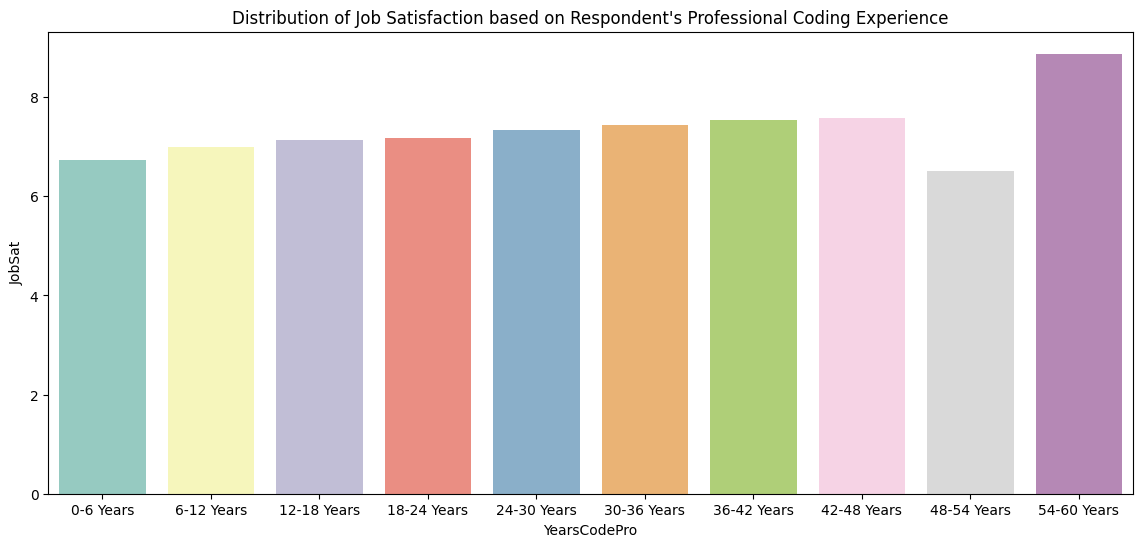

In [164]:
plt.figure(figsize=(14,6))
sns.barplot(df, x='YearsCodePro', y='JobSat', hue='YearsCodePro', palette='Set3')
plt.title("Distribution of Job Satisfaction based on Respondent's Professional Coding Experience")

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [165]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
